<a href="https://colab.research.google.com/github/Meemansha-spec/EDA-with-Pandas/blob/main/Churn_Feature_engineering_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
churn_data = pd.read_csv('telecom_customer_churn_cleaned.csv')

In [3]:
data = churn_data.copy()

In [4]:
churn_data.head().T

,0,1,2,3,4
customer_id,0002-ORFBO,0003-MKNFE,0004-TLHLJ,0011-IGKFF,0013-EXCHZ
gender,0,1,1,1,0
age,37,46,50,78,75
married,1,0,0,1,1
number_of_dependents,0,0,0,0,0
city,Frazier Park,Glendale,Costa Mesa,Martinez,Camarillo
zip_code,93225,91206,92627,94553,93010
latitude,34.827662,34.162515,33.645672,38.014457,34.227846
longitude,-118.999073,-118.203869,-117.922613,-122.115432,-119.079903
number_of_referrals,2,0,0,1,3


## Chapter 1: Who stayed and who left?
- When customer takes a service or purchases a product , they expect value for money, good quality of product or service or solution of the problems. There can be many factors of a person staying or leaving. In this dataset we will see the analysis of telecom dataset which will the tell the story of the company.

##### First of all let's plot the pie chart to visualize the `customer_status` of how many stayed and how many left.

<Axes: ylabel='count'>

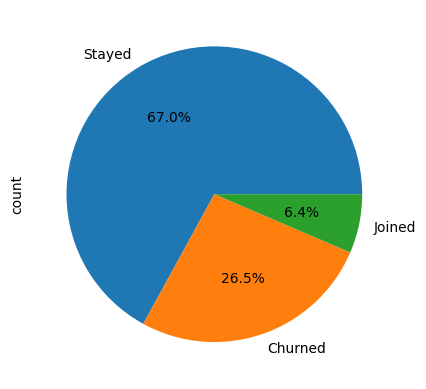

In [5]:
churn_data['customer_status'].value_counts().plot.pie(autopct='%1.1f%%')

In [6]:
churn_data['churn_reason'].value_counts()

,count
churn_reason,
Not Churned,5174
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78


<Axes: ylabel='count'>

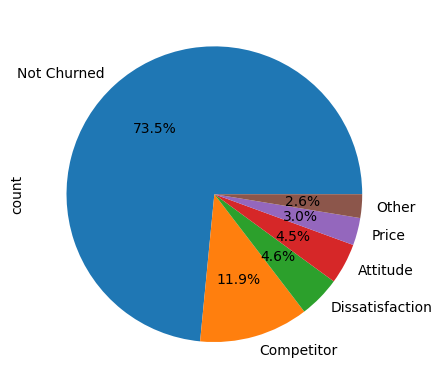

In [7]:
churn_data['churn_category'].value_counts().plot.pie(autopct='%1.1f%%')

In [8]:
churn_data[['customer_status','contract','age','tenure_in_months']]

,customer_status,contract,age,tenure_in_months
0,Stayed,One Year,37,9
1,Stayed,Month-to-Month,46,9
2,Churned,Month-to-Month,50,4
3,Churned,Month-to-Month,78,13
4,Churned,Month-to-Month,75,3
...,...,...,...,...
7038,Stayed,One Year,20,13
7039,Churned,Month-to-Month,40,22
7040,Joined,Month-to-Month,22,2
7041,Stayed,Two Year,21,67


## Chapter 1

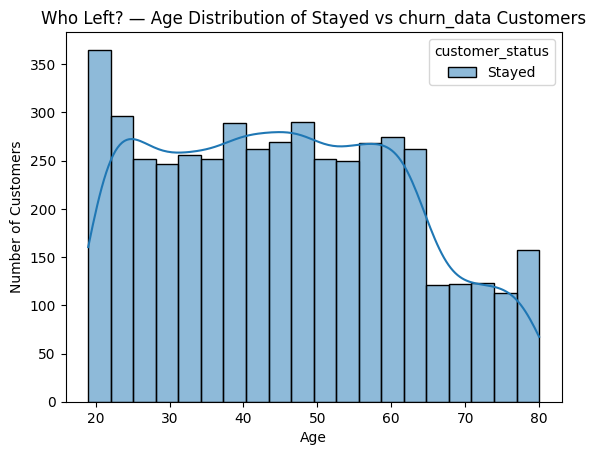

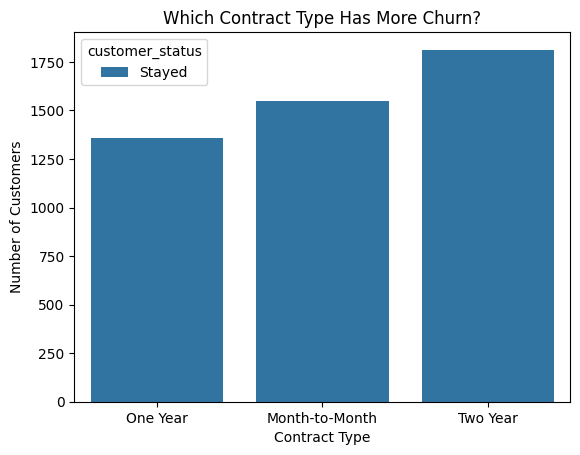

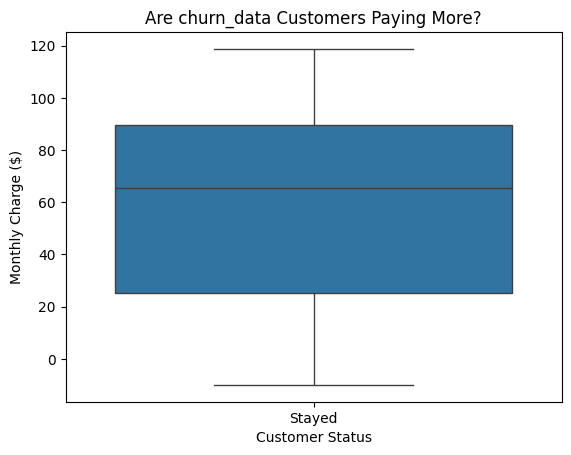

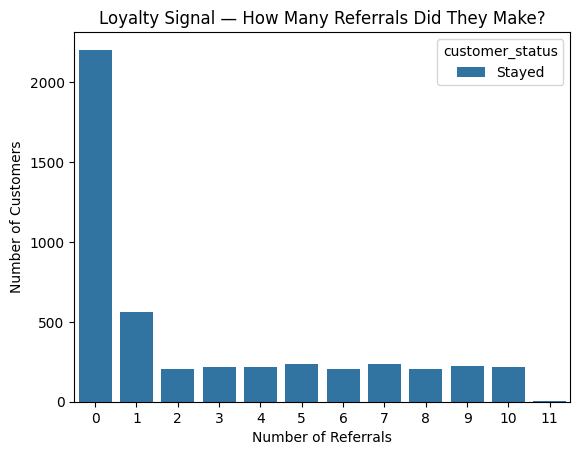

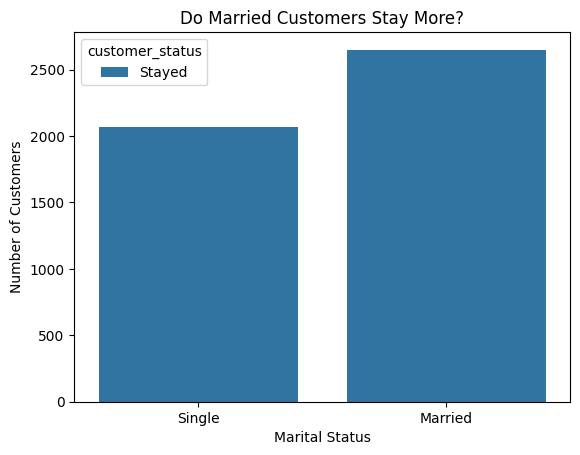

In [16]:
# Keep only Stayed and churn_data customers
churn_data = churn_data[churn_data['customer_status'].isin(['Stayed', 'churn_data'])]

# ── Plot 1: Age Distribution ──────────────────────────────────
sns.histplot(data=churn_data, x='age', hue='customer_status', bins=20, kde=True)
plt.title('Who Left? — Age Distribution of Stayed vs churn_data Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

# ── Plot 2: Contract Type ─────────────────────────────────────
sns.countplot(data=churn_data, x='contract', hue='customer_status')
plt.title('Which Contract Type Has More Churn?')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# ── Plot 3: Monthly Charge ────────────────────────────────────
sns.boxplot(data=churn_data, x='customer_status', y='monthly_charge')
plt.title('Are churn_data Customers Paying More?')
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charge ($)')
plt.show()

# ── Plot 4: Referrals ─────────────────────────────────────────
sns.countplot(data=churn_data, x='number_of_referrals', hue='customer_status')
plt.title('Loyalty Signal — How Many Referrals Did They Make?')
plt.xlabel('Number of Referrals')
plt.ylabel('Number of Customers')
plt.show()

# ── Plot 5: Marital Status ────────────────────────────────────
sns.countplot(data=churn_data, x='married', hue='customer_status')
plt.xticks([0, 1], ['Single', 'Married'])
plt.title('Do Married Customers Stay More?')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.show()


    number_of_referrals  churn_rate_%
0                     0     36.107889
1                     1     47.338936
2                     2     11.353712
3                     3     12.955466
4                     4      7.725322
5                     5      8.235294
6                     6      3.738318
7                     7      2.469136
8                     8      0.970874
9                     9      1.769912
10                   10      0.000000
11                   11      0.000000


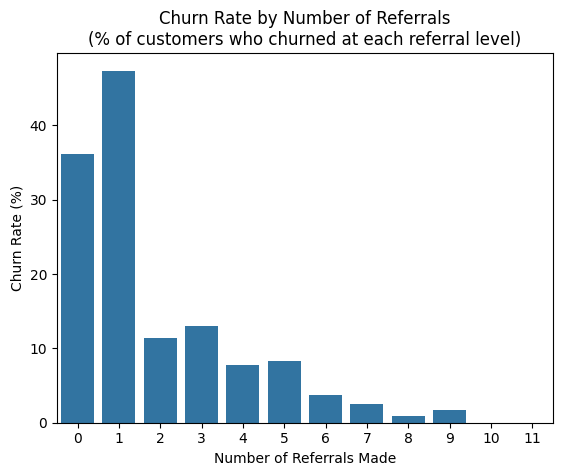

In [13]:
# Create a churn flag — 1 if churn_data, 0 if stayed
churn_data['churn_data'] = (churn_data['customer_status'] == 'churn_data').astype(int)

# Calculate churn RATE at each referral number
# i.e. out of everyone with 5 referrals, what % churn_data?
churn_rate_by_referral = churn_data.groupby('number_of_referrals')['churn_data'].mean() * 100
churn_rate_by_referral = churn_rate_by_referral.reset_index()
churn_rate_by_referral.columns = ['number_of_referrals', 'churn_rate_%']

print(churn_rate_by_referral)

# Plot churn rate by referral
sns.barplot(data=churn_rate_by_referral, x='number_of_referrals', y='churn_rate_%')
plt.title('Churn Rate by Number of Referrals\n(% of customers who churn_data at each referral level)')
plt.xlabel('Number of Referrals Made')
plt.ylabel('Churn Rate (%)')
plt.show()

## Chapter 2

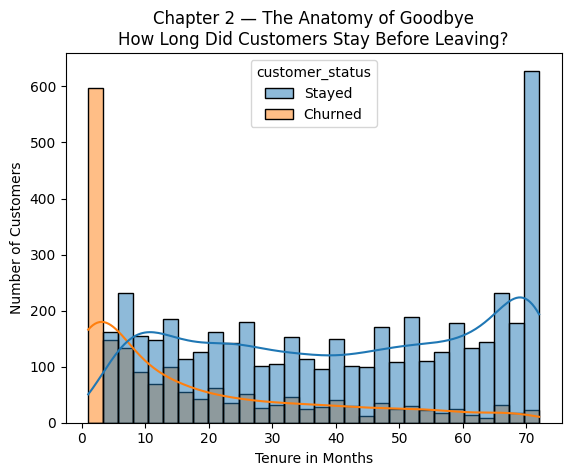

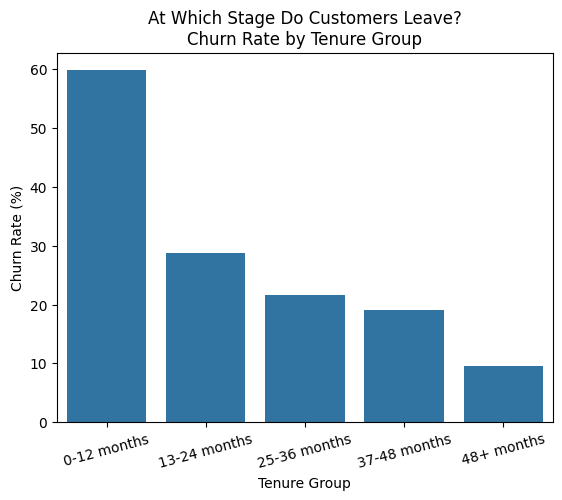

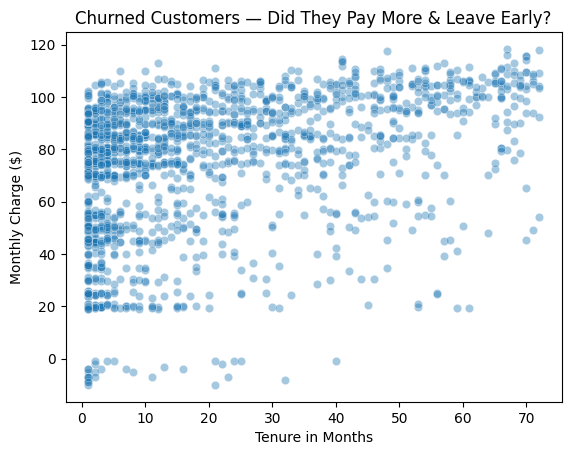

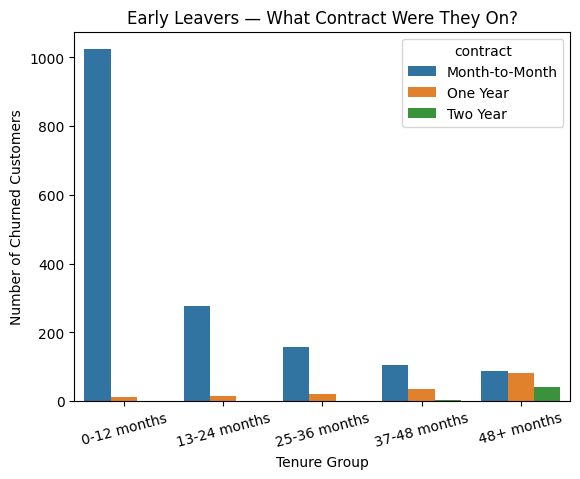

In [14]:
# Create tenure groups — life stages of a customer
bins   = [0, 12, 24, 36, 48, 72]
labels = ['0-12 months', '13-24 months', '25-36 months', '37-48 months', '48+ months']
churn_data['tenure_group'] = pd.cut(churn_data['tenure_in_months'], bins=bins, labels=labels)

# ── Plot 1: Tenure Distribution — Stayed vs churn_data ───────────
# This shows HOW LONG each group stayed before leaving or staying
sns.histplot(data=churn_data, x='tenure_in_months', hue='customer_status', bins=30, kde=True)
plt.title('Chapter 2 — The Anatomy of Goodbye\nHow Long Did Customers Stay Before Leaving?')
plt.xlabel('Tenure in Months')
plt.ylabel('Number of Customers')
plt.show()

# ── Plot 2: Churn Rate by Tenure Group ────────────────────────
# This shows at which life stage customers are most at risk
churn_by_tenure = churn_data.groupby('tenure_group')['churn_data'].mean() * 100
churn_by_tenure = churn_by_tenure.reset_index()
churn_by_tenure.columns = ['tenure_group', 'churn_rate_%']

sns.barplot(data=churn_by_tenure, x='tenure_group', y='churn_rate_%')
plt.title('At Which Stage Do Customers Leave?\nChurn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.show()

# ── Plot 3: Tenure vs Monthly Charge — Does price push them out?
# churn_data customers only — were they paying more AND leaving early?
churn_data_only = churn_data[churn_data['customer_status'] == 'churn_data']
sns.scatterplot(data=churn_data_only, x='tenure_in_months', y='monthly_charge', alpha=0.4)
plt.title('churn_data Customers — Did They Pay More & Leave Early?')
plt.xlabel('Tenure in Months')
plt.ylabel('Monthly Charge ($)')
plt.show()

# ── Plot 4: Tenure Group vs Contract Type ─────────────────────
# Were early leavers mostly on month to month contracts?
sns.countplot(data=churn_data[churn_data['customer_status'] == 'churn_data'],
              x='tenure_group', hue='contract')
plt.title('Early Leavers — What Contract Were They On?')
plt.xlabel('Tenure Group')
plt.ylabel('Number of churn_data Customers')
plt.xticks(rotation=15)
plt.show()

## Chapter 3

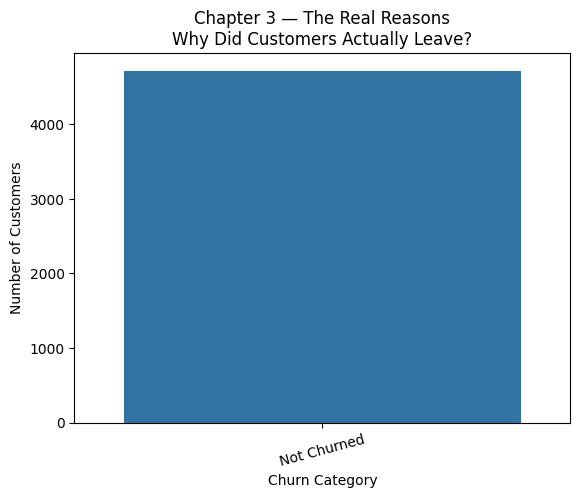

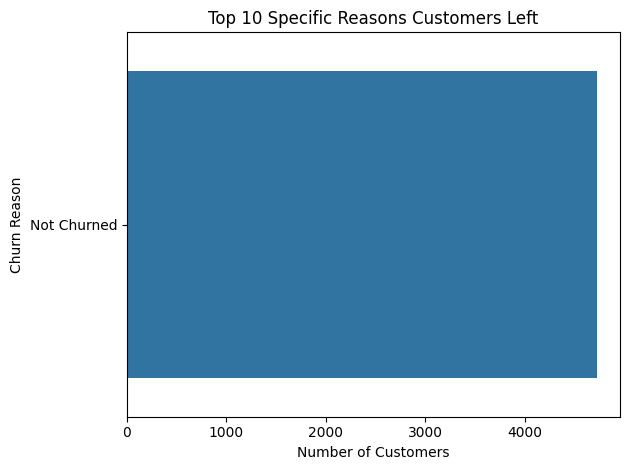

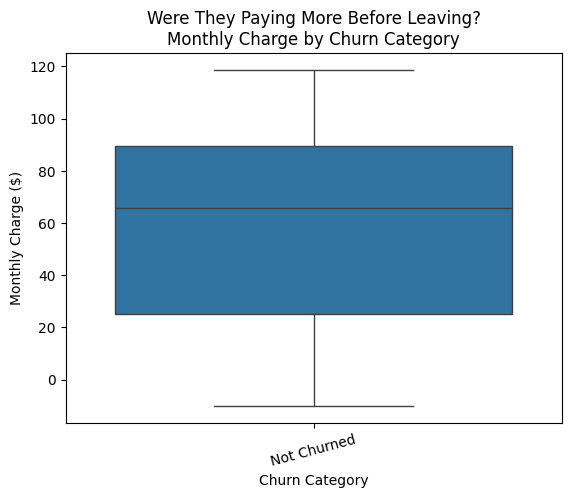

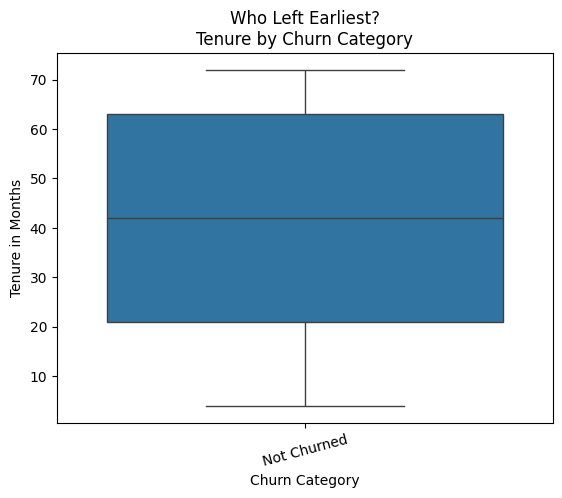

In [17]:

# ── Plot 1: Churn Category Overview ───────────────────────────
# The big picture — why did people leave overall?
category_counts = churn_data['churn_category'].value_counts().reset_index()
category_counts.columns = ['churn_category', 'count']

sns.barplot(data=category_counts, x='churn_category', y='count')
plt.title('Chapter 3 — The Real Reasons\nWhy Did Customers Actually Leave?')
plt.xlabel('Churn Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

# ── Plot 2: Top 10 Specific Churn Reasons ─────────────────────
# Going deeper — what exactly did they say?
top_reasons = churn_data['churn_reason'].value_counts().head(10).reset_index()
top_reasons.columns = ['churn_reason', 'count']

sns.barplot(data=top_reasons, x='count', y='churn_reason')
plt.title('Top 10 Specific Reasons Customers Left')
plt.xlabel('Number of Customers')
plt.ylabel('Churn Reason')
plt.tight_layout()
plt.show()

# ── Plot 3: Monthly Charge by Churn Category ──────────────────
# Were people who left for price actually paying more?
sns.boxplot(data=churn_data, x='churn_category', y='monthly_charge')
plt.title('Were They Paying More Before Leaving?\nMonthly Charge by Churn Category')
plt.xlabel('Churn Category')
plt.ylabel('Monthly Charge ($)')
plt.xticks(rotation=15)
plt.show()

# ── Plot 4: Tenure by Churn Category ──────────────────────────
# Who left earliest — attitude problems or price problems?
sns.boxplot(data=churn_data, x='churn_category', y='tenure_in_months')
plt.title('Who Left Earliest?\nTenure by Churn Category')
plt.xlabel('Churn Category')
plt.ylabel('Tenure in Months')
plt.xticks(rotation=15)
plt.show()

## Chapter 4

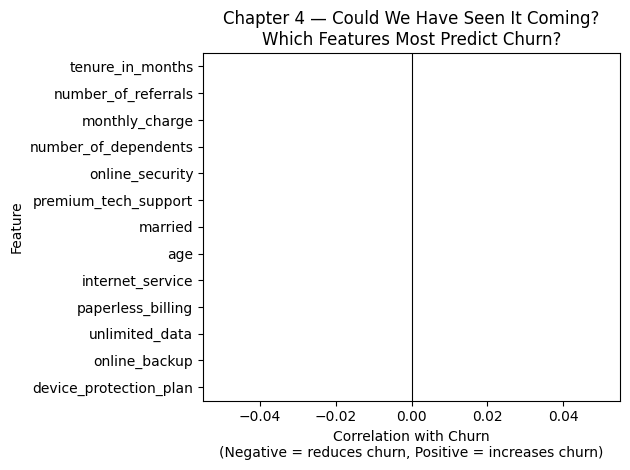

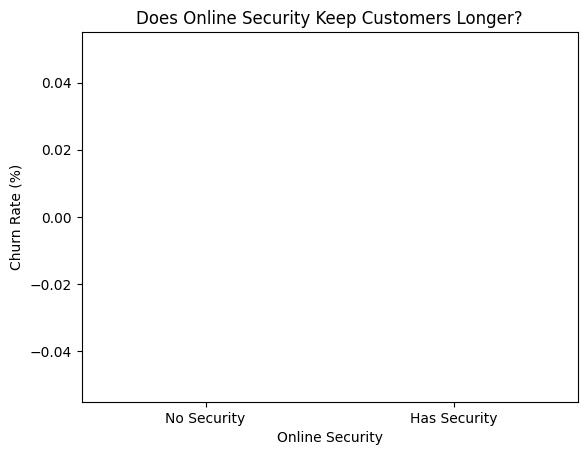

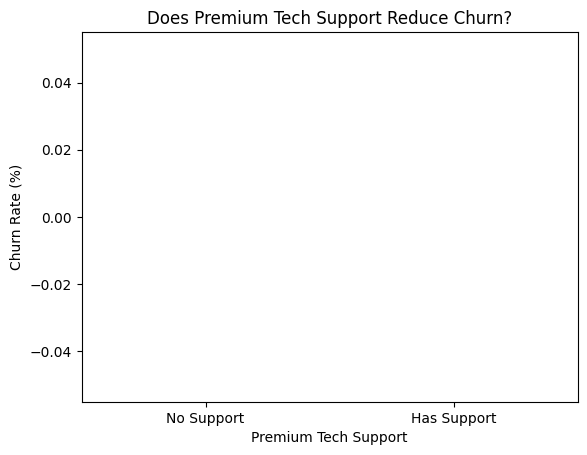

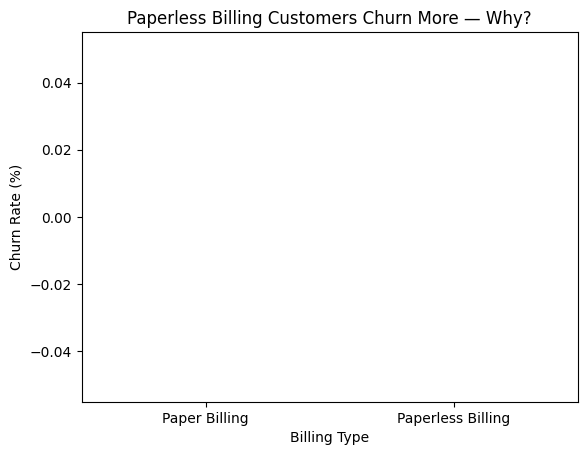

In [18]:
# ── Plot 1: Correlation of all features with churn ────────────
# Which features most predict churn — positive or negative?
numerical_cols = [
    'tenure_in_months', 'number_of_referrals', 'monthly_charge',
    'number_of_dependents', 'online_security', 'premium_tech_support',
    'married', 'age', 'internet_service', 'paperless_billing',
    'unlimited_data', 'online_backup', 'device_protection_plan'
]

correlations = churn_data[numerical_cols + ['churned']].corr()['churned'].drop('churned').sort_values()

sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Chapter 4 — Could We Have Seen It Coming?\nWhich Features Most Predict Churn?')
plt.xlabel('Correlation with Churn\n(Negative = reduces churn, Positive = increases churn)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ── Plot 2: Online Security vs Churn ──────────────────────────
# Customers without online security churn more?
security_churn = churn_data.groupby('online_security')['churned'].mean() * 100
security_churn = security_churn.reset_index()
security_churn.columns = ['online_security', 'churn_rate_%']
security_churn['online_security'] = security_churn['online_security'].map({0: 'No Security', 1: 'Has Security'})

sns.barplot(data=security_churn, x='online_security', y='churn_rate_%')
plt.title('Does Online Security Keep Customers Longer?')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')
plt.show()

# ── Plot 3: Premium Tech Support vs Churn ─────────────────────
# Does feeling supported make customers stay?
support_churn = churn_data.groupby('premium_tech_support')['churned'].mean() * 100
support_churn = support_churn.reset_index()
support_churn.columns = ['premium_tech_support', 'churn_rate_%']
support_churn['premium_tech_support'] = support_churn['premium_tech_support'].map({0: 'No Support', 1: 'Has Support'})

sns.barplot(data=support_churn, x='premium_tech_support', y='churn_rate_%')
plt.title('Does Premium Tech Support Reduce Churn?')
plt.xlabel('Premium Tech Support')
plt.ylabel('Churn Rate (%)')
plt.show()

# ── Plot 4: Paperless Billing vs Churn ────────────────────────
# Interesting — paperless billing is positively correlated with churn
billing_churn = churn_data.groupby('paperless_billing')['churned'].mean() * 100
billing_churn = billing_churn.reset_index()
billing_churn.columns = ['paperless_billing', 'churn_rate_%']
billing_churn['paperless_billing'] = billing_churn['paperless_billing'].map({0: 'Paper Billing', 1: 'Paperless Billing'})

sns.barplot(data=billing_churn, x='paperless_billing', y='churn_rate_%')
plt.title('Paperless Billing Customers Churn More — Why?')
plt.xlabel('Billing Type')
plt.ylabel('Churn Rate (%)')
plt.show()